 # Random Number Generators

 **Questions**:
 - How do we generate a random number? (e.g. From atmospheric noise: https://www.random.org/)
 - How easy are these to implement?
 - How efficient are they?
 - How "random" is a random number?

 ![](https://imgs.xkcd.com/comics/random_number.png)
 ---
 ![](https://archive.md/1y5R9/27f4fdaec705df513864e63dde476a7396c387fc.gif)

 ### Generator expressions, generator functions

 Detailed usage instructions on RealPython

In [2]:
from typing import Iterator, Iterable


def infinite_sequence() -> Iterator[int]:
    num = 0
    while True:
        yield num
        num += 1


In [3]:
seq = infinite_sequence()
seq


<generator object infinite_sequence at 0x7f786a50eec0>

In [4]:
next(seq)


0

In [5]:
next(seq)


1

 ## Linear Congruential Generators

 Let $m \geq 2$ and $a, b \in \{1,2,\dots,m-1\}$.
 Then the $$x_n = ax_{n-1} + b \mod{m}$$ relation generates the $x_1,x_2,\dots$ sequence.

 $x_0$ is called the seed.

In [6]:
def lcg(a: int, b: int, seed: int, m: int) -> Iterator[int]:
    x = seed
    while True:
        x = (a*x + b) % m
        yield x


 **Example**: Let $a=3, b=5, x_0=0, m=31$

In [7]:
rng = lcg(3, 5, 0, 31)
[next(rng) for _ in range(20)]


[5, 20, 3, 14, 16, 22, 9, 1, 8, 29, 30, 2, 11, 7, 26, 21, 6, 23, 12, 10]

 **Example**: Let $a=65539, b=0, x_0=1, m=2^{31}$.

In [8]:
randu = lcg(65539, 0, 1, 2 ** 31)
[next(randu) for _ in range(20)]


[65539,
 393225,
 1769499,
 7077969,
 26542323,
 95552217,
 334432395,
 1146624417,
 1722371299,
 14608041,
 1766175739,
 1875647473,
 1800754131,
 366148473,
 1022489195,
 692115265,
 1392739779,
 2127401289,
 229749723,
 1559239569]

In [9]:
import matplotlib.pyplot as plt

def plot_2d_spectral_test(seq: list) -> tuple:
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.scatter(seq[:-1], seq[1:], marker='o')
    return fig, ax

def plot_3d_spectral_test(seq: list, elev: int, azim: int) -> tuple:
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(seq[:-2], seq[1:-1], seq[2:], marker='o')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.view_init(elev=elev, azim=azim)
    return fig, ax


(<Figure size 1000x1000 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

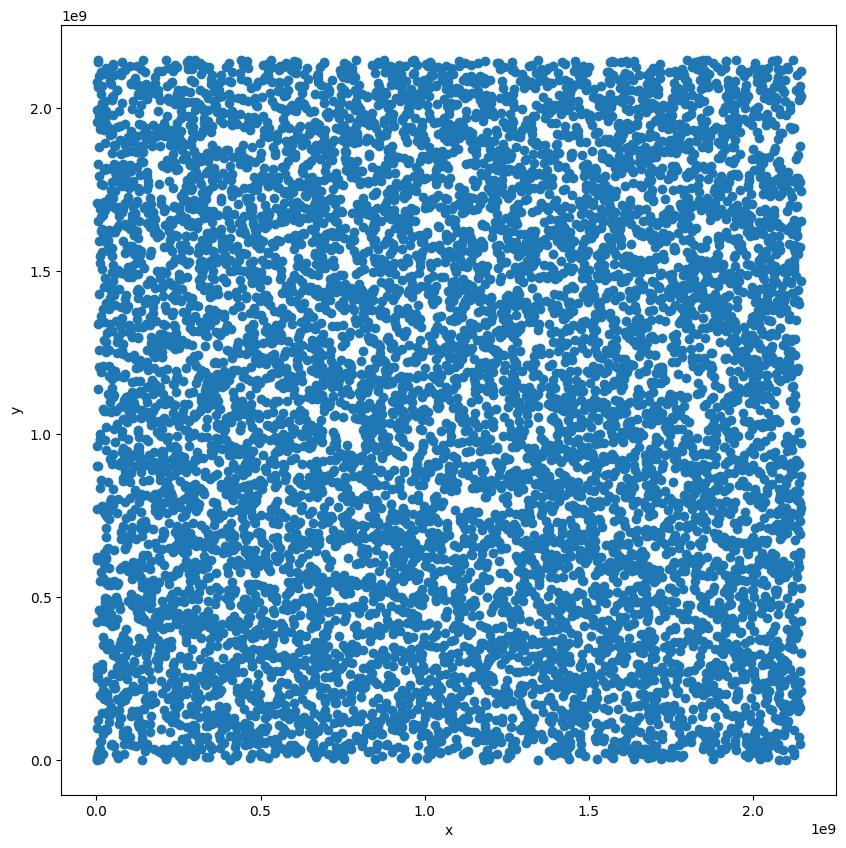

In [10]:
randu = lcg(65539, 0, 1, 2 ** 31)
seq = [next(randu) for _ in range(10000)]
plot_2d_spectral_test(seq)


(<Figure size 1000x1000 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

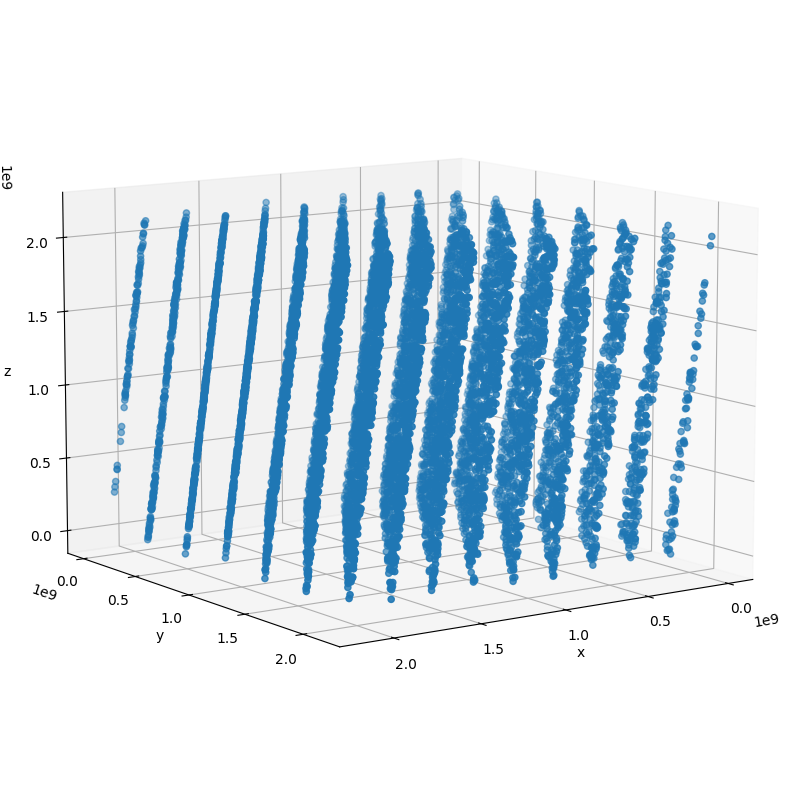

In [11]:
plot_3d_spectral_test(seq, 10, 55)


 When will an LCG generator be a "good" generator (i.e., when will the length of its period be maximal)?
 - $b$ and $m$ are relative primes
 - for every prime number $p$ that divides $m$, $a - 1$ is a multiple of $p$
 - $a - 1$ is a multiple of $4$ if $m$ is a multiple of $4$

 Theoretical article: https://dl.acm.org/doi/10.1145/63039.63042

 These parameters will all be good:
 1. $a=65539, b=1, x_0=0, m=2^{31}$.
 2. $a=31, b=13, x_0 = 7, m=60$
 3. $a=5, b=5, x_0=3, m=8$

 Further LCG-type generators:

 - $x_n = (ax_{n-1}^2 + bx_{n-1} + c) \mod{m}$
 - $x_n = (ax_{n-1}^3 + bx_{n-1}^2 + cx_{n-1} + d) \mod{m}$

 ### **LCG-TYPE GENERATORS ARE NOT SECURE!**

 https://www.cs.umd.edu/~gasarch/COURSES/456/F18/notes/crackrand.pdf

 But they can be combined: not safer, but longer period.

 **Example**: Let $x_0 = 3, a = 91, b = 52, m = 255$, i.e., our LCG generator is: $$x_{n+1} = 91x_n + 52 \mod{255}$$

In [12]:
def otp_gen(rng: Iterable[int], k: int) -> bytes:
    return bytes(next(rng) for _ in range(k))

def otp_enc(key: bytes, plaintext: bytes) -> bytes:
    ct = b""
    for k, char in zip(key, plaintext):
        ct += (k ^ char).to_bytes(1, byteorder='big')
    return ct

def otp_dec(key: bytes, ciphertext: bytes) -> bytes:
    return otp_enc(key, ciphertext)


In [13]:
plaintext = b"2025-02-28: LCG random number generators are generally not secure."
rng = lcg(91, 52, 3, 255)
key = otp_gen(rng, len(plaintext))
ciphertext = otp_enc(key, plaintext)
print(f"Ciphertext: {ciphertext}")
decrypted_text = otp_dec(key, ciphertext)
print(f"Decrypted text: {decrypted_text}")


Ciphertext: b't\x1f\xcb%\xc4j`Z\x99\x02\xdch\xa9\xaf+\x9ep\x8b\xdb\xaf\xca{.]\x12\x98\xc0a\xd3\x88O\x1f\xd3\xc3\x03\xe6\x15\xbe\xbb\x9d\x03\xd0,\xda}\x03\x86X\x1c\x10L/q\xf4\xa5\xc4\xb1\x19:\x08|C\xea\x83P0'
Decrypted text: b'2025-02-28: LCG random number generators are generally not secure.'


 Let's assume we know some part of the message, in this case that it starts with a timestamp and it was sent this year. We can use this information to crack the generator:

 #### 1. Find $m$

 We recover $m$ by first defining $t_i = x_{i+1} - x_i$ and then calculating $u_i = |t_{i+2}t_i - t_{i+1}^2|$. The greatest common divisor of the $u_i$ values will be $m$ or a multiple of it.
 The more elements we have, the more likely we are to get the correct $m$ (the probability that two random numbers are relatively prime is $\frac{6}{\pi^2}$, with more numbers, it increases exponentially).

 This is correct, because

 \begin{align*}
 t_i &= x_{i+1} - x_i \\
 t_{i+1} &= x_{i+2} - x_{i+1} \equiv ax_{i+1} + b - ax_i - b \equiv a(x_{i+1} - x_i) \equiv at_i \mod{m} \\
 t_{i+2} &= x_{i+3} - x_{i+2} \equiv ax_{i+2} + b - ax_{i+1} - b \equiv a(x_{i+2} - x_{i+1}) \equiv a^2t_i \mod{m} \\
 u_i &\equiv |t_{i+2}t_i - t_{i+1}^2| \equiv |a^2t_i^2 - a^2t_i^2| \equiv 0 \mod{m}
 \end{align*}

In [14]:
from math import gcd
from typing import Sequence

def recover_m(seq: Sequence[int]) -> int:
    t = [seq[i+1] - seq[i] for i in range(len(seq)-1)]
    print(t)
    u = [abs(t[i+2] * t[i] - t[i+1]**2) for i in range(len(t)-2)]
    print(u)
    m = gcd(*u)
    return m

rec_key = otp_enc(b"2025-", ciphertext[:5])
m = recover_m(rec_key)
print(f"Recovered m: {m}")


[-23, 202, -233, 217]
[35445, 10455]
Recovered m: 255


 #### 2. Find $a$ and $b$

 We can find $a$ and $b$ by solving the following system of equations:

 \begin{align*}
 x_1 &= ax_0 + b \mod{m} \\
 x_2 &= ax_1 + b \mod{m}
 \end{align*}

 So:

 \begin{align*}
 x_2 - x_1 &= a(x_1 - x_0) \mod{m} \\
 a &= (x_2 - x_1)(x_1 - x_0)^{-1} \mod{m} \\
 b &= x_1 - ax_0 \mod{m}
 \end{align*}

In [15]:
def recover_ab(seq: Sequence[int], m: int) -> tuple:
    a = (seq[2] - seq[1]) * pow(seq[1] - seq[0], -1, m) % m
    b = (seq[1] - a * seq[0]) % m
    return a, b

a, b = recover_ab(rec_key, m)
print(f"Recovered a: {a}, Recovered b: {b}")


Recovered a: 91, Recovered b: 52


 #### 3. Decrypt the message

 We can now decrypt the message using the recovered key.

In [16]:
otp_dec(otp_gen(lcg(a, b, rec_key[0], m), len(ciphertext)-1), ciphertext[1:])


b'025-02-28: LCG random number generators are generally not secure.'

 To find the exact seed, we need to find the period first.

In [17]:
def find_period(rng: Iterable[int]) -> int:
    first = next(rng)
    i = 1
    while next(rng) != first:
        i += 1
    return i

rng = lcg(a, b, rec_key[0], m)
period = find_period(rng)
period


240

In [18]:
rng = lcg(a, b, rec_key[0], m)
rec_seed = [next(rng) for _ in range(period-1)][-1]
rec_seed


3

In [19]:
rng = lcg(a, b, rec_seed, m)
rec_key = otp_gen(rng, len(ciphertext))
otp_dec(rec_key, ciphertext)


b'2025-02-28: LCG random number generators are generally not secure.'

 # Stream ciphers and random number generators

 ![](./stream_cipher.png)

 ## Linear Feedback Shift Registers (LFSR)
# Linear Feedback Shift Registers (LFSR)

 Some concepts:
 - Every LFSR consists of $n$ registers: $s_{n-1},\dots,s_0$
 - Alongside the registers, there are $n$ *feedback coefficients*: $c_{n-1},\dots,c_0$
 - The *degree* of the LFSR is the number of registers, $n$
 - Each register stores one bit
 - The state update: we shift the contents of the registers one step to the right, and we calculate the leftmost register based on the feedback coefficients
 - An LFSR state is the current content of the registers, formally: let the state at time $t$ be $s^{(t)}_{n-1}, \dots, s^{(t)}_0$. We calculate the next state $s^{(t+1)}_{n-1},\dots,s^{(t+1)}_0$ as follows:

 \begin{align*}
 s^{(t+1)}_i &:= s^{(t)}_{i+1} \\
 s^{(t+1)}_{n-1} &:= \bigoplus^{n-1}_{i=0} c_i s^{(t)}_{i}
 \end{align*}

 - The bit generated by the LFSR is the output of the rightmost register.

 ![](./lfsr.png)

In [20]:
from functools import reduce
from operator import xor
from typing import Callable

def lfsr(seed: list[int], coeffs: list[int], f: Callable[[int, int], int] = xor) -> Iterator[int]:
    state = seed
    while True:
        t = reduce(f, (i*j for i, j in zip(state, coeffs)))
        yield state.pop()
        state = [t, *state]


def bits_to_bytes(bits: list[int]) -> bytes:
    """
    Convert a list of bits to a bytes object.
    """
    return bytes(int(''.join(map(str, bits[i:i+8])), 2) for i in range(0, len(bits), 8))

def bytes_to_bits(byte: bytes) -> list[int]:
    """
    Convert a bytes object to a list of bits.
    """
    return [int(b) for byte in byte for b in f"{byte:08b}"]


In [21]:
rng = lfsr([0, 1, 1, 0], [0, 0, 1, 1])
plaintext = b"I am a LFSR."

key_bits = [next(rng) for _ in range(8 * len(plaintext))]
print(f"Key bits: {key_bits}")
key = bits_to_bytes(key_bits)
print(f"Key: {key}")
ciphertext = otp_enc(key, plaintext)
print(f"Ciphertext: {ciphertext}")
decrypted_text = otp_dec(key, ciphertext)
print(f"Decrypted text: {decrypted_text}")

Key bits: [0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0]
Key: b'k\xc4\xd7\x89\xaf\x13^&\xbcMx\x9a'
Ciphertext: b'"\xe4\xb6\xe4\x8fr~j\xfa\x1e*\xb4'
Decrypted text: b'I am a LFSR.'


In [74]:
rng = lfsr([0, 0, 1, 1], [0, 1, 0, 1], f=lambda x, y: 1 - (x ^ y))
[next(rng) for _ in range(20)]


[1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]

In [75]:
rng = lfsr([0, 0, 1, 1], [0, 1, 1, 1], f=lambda x, y: 1 - (x ^ y))
[next(rng) for _ in range(40)]


[1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0]

 Questions:
 - What could be the period of an LFSR?
   - The period of an LFSR is at most $2^n - 1$, where $n$ is the degree of the LFSR.
 - Is there a state that becomes a fixed point of the LFSR?
   - Yes, e.g. the all-zero state.
 - What could determine the length of the LFSR's period?
   - The feedback coefficients, namely the irreducibility of the polynomial defined by the feedback coefficients.
 ## Definition (Irreducible polynomial):
 A polynomial $p(x) = a_0 + a_1x + \cdots + a_nx^n$ is irreducible over a field $F$ if it cannot be factored into the product of two non-constant polynomials in $F[x]$.

 **Example**: The polynomial $x^2 + x + 1$ is irreducible over $\mathbb{Z}_2$.
 The polynomial $x^2 + 1$ is reducible over $\mathbb{Z}_2$ because it can be factored into $(x+1)(x+1)$.

 ## LFSR cracking
 Problem: the next bit can be predicted $\rightarrow$ *reconstruction attack*
 - The LFSR state at any later time can be reconstructed from $\leq 2n$ observed bits

 **Task:** Given the following `seq`, a bit sequence generated by an LFSR. The degree of the LFSR is unknown. Determine the feedback coefficients!

 **Solution:** In each step, we will create a system of linear equations, then based on the solution of that, we check whether all the other elements of the sequence can be calculated with the coefficients obtained this way.
 - Let $n=2$ ($n=1$ would give us a constant sequence, so we skip that). The system of linear equations:
 \begin{align*}
 c_0 \cdot 0 \oplus c_1 \cdot 1 &= 1 \\
 c_0 \cdot 1 \oplus c_1 \cdot 1 &= 0
 \end{align*}
 In matrix form:
 \begin{equation*}
 \begin{pmatrix}
 0 & 1 \\
 1 & 1
 \end{pmatrix}
 \begin{pmatrix}
 c_0 \\
 c_1
 \end{pmatrix} =
 \begin{pmatrix}
 1 \\
 0
 \end{pmatrix}
 \end{equation*}
 The solution is $c_0 = 1, c_1 = 1$, but this is not good, because $x_4 \oplus x_5 = 0 \oplus 1 \ne 0$
 - Let $n = 3$:
 \begin{equation*}
 \begin{pmatrix}
 0 & 1 & 1 \\
 1 & 1 & 0 \\
 1 & 0 & 1
 \end{pmatrix}
 \begin{pmatrix}
 c_0 \\ c_1 \\ c_2
 \end{pmatrix} =
 \begin{pmatrix}
 0 \\ 1 \\ 0
 \end{pmatrix}
 \end{equation*}
 Since the determinant of the matrix is $0 \mod{2}$, the above system of equations has no solution.
 - Let $n = 4$:
 \begin{equation*}
 \begin{pmatrix}
 0 & 1 & 1 & 0 \\
 1 & 1 & 0 & 1 \\
 1 & 0 & 1 & 0 \\
 0 & 1 & 0 & 1
 \end{pmatrix}
 \begin{pmatrix}
 c_0 \\ c_1 \\ c_2 \\ c_3
 \end{pmatrix} =
 \begin{pmatrix}
 1 \\ 0 \\ 1 \\ 1
 \end{pmatrix}
 \end{equation*}
 The solution is $c_0 = 1, c_1 = 1, c_2 = 0, c_3 = 0$, which will already produce the correct sequence.

 In general:

 \begin{equation*}
 \begin{pmatrix}
 x_1 & x_2 & \cdots & x_n \\
 x_2 & x_3 & \cdots & x_{n+1} \\
 \vdots & \vdots & \ddots & \vdots \\
 x_n & x_{n+1} & \cdots & x_{2n-1}
 \end{pmatrix}
 \begin{pmatrix}
 c_0 \\ c_1 \\ \vdots \\ c_{n-1}
 \end{pmatrix} =
 \begin{pmatrix}
 x_{n+1} \\ x_{n+2} \\ \vdots \\ x_{2n}
 \end{pmatrix}
 \end{equation*}

In [76]:
import numpy as np

ciphertext = b'Y\xf4\xe5\xbc\x82#l\x0b\x8euB\xba\xbds\xb19\xe4\xa5\xe8\xc1w1K\x9c#\r\xf7\x93P\x90K\xa3\xb2\xe7\xcaa?R\xd3?\x0b\xba\x90G\x87K\xa5\xbb\xfa\xc030I\xc8m\x0b\xff\x92@\x90\x0e\xea'
plaintext_start = b'2025'
recovered_key_bits = bytes_to_bits(otp_enc(plaintext_start, ciphertext[:len(plaintext_start)]))
print(f"Recovered key bits: {recovered_key_bits}")
# [0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1]

def solve_mod2(mat: np.ndarray, vec: np.ndarray) -> np.ndarray:
    """
    Solve a system of linear equations over GF(2) (binary field)
    Args:
        mat: numpy array representing the coefficient matrix
        vec: numpy array representing the right-hand side vector
    Returns:
        numpy array containing the solution vector
    """
    # Convert to int arrays and take modulo 2
    A = mat.astype(int) % 2
    b = vec.astype(int) % 2
    n = len(A)
    
    # Augment the matrix with the vector
    aug = np.column_stack((A, b))
    
    # Forward elimination
    for i in range(n):
        # Find pivot
        pivot_row = i
        while pivot_row < n and aug[pivot_row, i] == 0:
            pivot_row += 1
            
        if pivot_row == n:
            raise Exception("No unique solution exists")
            
        # Swap rows if necessary
        if pivot_row != i:
            aug[i], aug[pivot_row] = aug[pivot_row].copy(), aug[i].copy()
            
        # Eliminate below
        for j in range(i + 1, n):
            if aug[j, i] == 1:
                aug[j] = (aug[j] + aug[i]) % 2
                
    # Back substitution
    x = np.zeros(n, dtype=int)
    for i in range(n-1, -1, -1):
        x[i] = aug[i, -1]
        for j in range(i+1, n):
            x[i] = (x[i] + aug[i,j] * x[j]) % 2
            
    return x    

def break_coeffs(seq: list[int]) -> tuple[int, list[int]]:
    n = 2
    while True:
        mat = np.array([seq[i:i+n] for i in range(n)])
        vec = np.array([seq[i+n] for i in range(n)])

        try:
            cand_coeff = solve_mod2(mat, vec)
        except Exception:
            n += 1
            continue
        cand_coeff = list(reversed([int(i) for i in list(cand_coeff)]))
        cand_seq_gen = lfsr(list(reversed(seq[:n])), cand_coeff)
        cand_seq = [next(cand_seq_gen) for _ in range(len(seq))]
        if cand_seq == seq:
            return n, cand_coeff
        n += 1

n, coeffs = break_coeffs(recovered_key_bits)
print(f"Recovered n: {n}, Recovered coefficients: {coeffs}")
rng = lfsr(list(reversed(recovered_key_bits[:n])), coeffs)
rec_key_bits_full = [next(rng) for _ in range(len(ciphertext) * 8)]
rec_key = bits_to_bytes(rec_key_bits_full)
decrypted_text = otp_dec(rec_key, ciphertext)
print(f"Decrypted text: {decrypted_text}")


Recovered key bits: [0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
Recovered n: 4, Recovered coefficients: [0, 0, 1, 1]
Decrypted text: b'2025-02-28: LFSR random number generators are also not secure.'


 How can the attack be made more difficult? **Nonlinear-feedback shift register (FSR)**:
 It's the same as before, but the function calculating the new value is nonlinear.

 ## Geffe generator

 It contains three LFSRs, A, B, and C, which give the outputs a,b,c. The secret key is given by $k = (a \wedge \neg b) \oplus (b \wedge c)$. The period is the least common multiple of the periods of the individual LFSRs.

 ![](./geffe.png)

In [39]:
import random

def geffe() -> Iterator[tuple[int, int, int, int]]:
    lfsr_a = lfsr(random.choices([0, 1], k=8), [1, 0, 1, 0, 0, 1, 1, 0])
    lfsr_b = lfsr(random.choices([0, 1], k=8), [1, 1, 1, 0, 0, 0, 0, 1])
    lfsr_c = lfsr(random.choices([0, 1], k=8), [1, 0, 1, 1, 1, 0, 0, 0])

    while True:
        a, b, c = next(lfsr_a), next(lfsr_b), next(lfsr_c)
        k = (1 & (1-b)) ^ (b & c)
        yield a, b, c, k


In [40]:
g = geffe()
[next(g) for _ in range(10)]


[(1, 0, 0, 1),
 (0, 1, 1, 1),
 (1, 1, 1, 1),
 (1, 0, 0, 1),
 (1, 0, 0, 1),
 (0, 0, 1, 1),
 (0, 0, 0, 1),
 (1, 0, 0, 1),
 (0, 0, 1, 1),
 (0, 1, 0, 0)]

 Further generators based on LFSR:
 - Jennings generator
 - Beth-Piper Stop-and-Go generator
 - Alternating Stop-and-Go generator
 - Threshold generator
 - Self-decimated generator
 - Multispeed Inner-product generator
 - Summation generator
 - (Self-)Shrinking generator
 - Feedback with Carry Shift Register
 - ...

 # Cryptographically Secure Generators

 These typically build on some difficult problem.

 ## Blum-Blum-Shub

 By Lenore Blum, Manuel Blum, and Michael Shub (1986)

 Let $p$ and $q$ be (large) prime numbers such that $p\,\text{mod}\,4 = q\,\text{mod}\,4 = 3$ and $M=pq$. Let the seed $x_0$ be relatively prime with $M$. Let $x_n = x_{n-1}^2 \mod{M}$ and the generated random bit be the last bit of $x_n$.

 Interesting fact: any $x_i$ value can be calculated directly: $x_i = \left( x_{0}^{2^i\mod{\lambda(M)}} \right) \mod{M}$, where $\lambda(M) = \text{lcm}(p-1, q-1)$.

 ## Blum-Micali Generator

 Let $p$ be a prime number and $q$ be an odd prime number. Let $x_0$ be the seed. Let $x_n = p^{x_{n-1}} \mod{q}$ and the generated random bit be $1$ if $x_{n-1} < (q-1)/2$, otherwise $0$.

 **Claim**: If $q$ is large enough, then the above relationship is difficult to calculate, and the generator is secure. (See also: discrete logarithm problem, later)

 ## RSA Generator

 Let $p$ and $q$ be large prime numbers. Let $N=pq$ and $e$ be such that it is relatively prime with the product $(p-1)(q-1)$. Let $x_0 < N$ be the seed. The generator: $x_{n} = x^e_{n-1} \mod{N}$, and the random bit is the least significant bit of $x_n$.

 **Claim**: If $p$ and $q$ are large enough, then the generator is secure. (See also: RSA, later)

 ## Statistical Tests

 - NIST: https://csrc.nist.gov/Projects/Random-Bit-Generation/Documentation-and-Software
 - Diehard: https://ani.stat.fsu.edu/diehard/
 - TestU1

 # Tasks

 1. Implement the above, cryptographically secure generators! Optionally, apply a statistical test to them.
 2. Implement the following, LCG type random number generators and determine the length of their periods and the first five elements of the sequences! Optionally, also look at the 2D and 3D spectral test on them (the code seen in the practice can be used for this)!
     1. The ACORN generator works as follows:
        - Choose an integer $k \geq 1$
        - Choose an $M$ and a seed $Y_0^{(0)}$ such that $0 < Y_0^{(0)} < M$ and $Y_0^{(0)}$ and $M$ are relatively prime
        - Choose $k$ arbitrary integers, $Y_0^{(1)}, Y_0^{(2)},\dots,Y_0^{(k)}$, such that $0 \leq Y_0^{(j)} < M$ for all $j=1,2,\dots,k$
        - Calculate the elements of the sequence: $$Y_{i}^{(j)} = \left( Y_{i}^{(j-1)} + Y_{i-1}^{(j)} \right) \mod{M},$$ for all $j = 1,2,\dots,k$
     2. L’Ecuyer MRG32k3a generator:
        \begin{align*}
            x_i &= (a_{11}x_{i-1} + a_{12}x_{i-2} + a_{13}x_{i-3}) \mod{m_1} \\
            y_i &= (a_{21}y_{i-1} + a_{22}y_{i-2} + a_{23}y_{i-3}) \mod{m_2} \\
            z_i &= (x_i - y_i) \mod{m_1} \\
            u_i &= (z_i + 1) / m_1,
        \end{align*}
        where $a_11 = 0$, $a_{12} = 1403580$, $a_{13} = -810728$, $m_1 = 2^{32} - 209$, $a_{21} = 527612$, $a_{22} = 0$, $a_{23} = -1370589$, $m_2 = 2^{32} - 22853$ and $u_i$ is an element of the sequence in the $(0,1]$ interval.
 3. Implement the exclusive OR generator (XORG)! The seed is 127 bits long, the i-th generated bit is given by $x_i = x_{i-1} \oplus x_{i-127}$
 4. Look up how the (Self-)Shrinking and the Feedback with Carry Shift Register generators work, then give an implementation as well!